In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer


class MovieGenreDataset(Dataset):
    def __init__(self, csv_file, image_data_path, text_features=['overview'], label_column='genres', tokenizer=None):
        self.data = pd.read_csv(csv_file)
        self.images = self._load_images(image_data_path)
        self.text_features = text_features
        self.tokenizer = tokenizer
        self.label_column = label_column
        self.mlb = MultiLabelBinarizer()
        self.labels = self._encode_labels()


        min_length = min(len(self.data), len(self.images), len(self.labels))
        self.data = self.data.iloc[:min_length]
        self.images = self.images[:min_length]
        self.labels = self.labels[:min_length]

    def _load_images(self, path):
        with open(path, 'rb') as f:
            return pickle.load(f)

    def _encode_labels(self):
        labels = self.data[self.label_column].apply(lambda x: eval(x) if isinstance(x, str) else [])
        return self.mlb.fit_transform(labels)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32).permute(2, 0, 1) / 255.0
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.tokenizer:
            combined_text = " ".join(str(self.data.loc[idx, col]) for col in self.text_features)
            encoding = self.tokenizer(combined_text, return_tensors='pt', padding='max_length',
                                     truncation=True, max_length=128)
            return image, encoding['input_ids'].squeeze(0), encoding['attention_mask'].squeeze(0), label
        else:
            return image, label

In [ ]:
import torch.nn as nn
from torchvision import models

class MultiModalClassifier(nn.Module):
    def __init__(self, num_classes, text_model=None):
        super(MultiModalClassifier, self).__init__()
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Linear(self.cnn.fc.in_features, 256)

        self.use_text = text_model is not None
        if self.use_text:
            self.text_model = text_model
            self.text_fc = nn.Linear(self.text_model.config.hidden_size, 256)

        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256 * (2 if self.use_text else 1), 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
            nn.Sigmoid()
        )

    def forward(self, image, input_ids=None, attention_mask=None):
        img_feat = self.cnn(image)

        if self.use_text:
            text_outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
            text_feat = self.text_fc(text_outputs.pooler_output)
            x = torch.cat([img_feat, text_feat], dim=1)
        else:
            x = img_feat

        return self.classifier(x)


In [ ]:
from transformers import BertTokenizer
import torch
import pickle
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertModel
import torch.nn.functional as F


tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
text_model = BertModel.from_pretrained('bert-base-uncased')

train_dataset = MovieGenreDataset(
    csv_file='/content/drive/My Drive/movie_recommendation/new_evaluation/train_updated.csv',
    image_data_path='/content/drive/My Drive/movie_recommendation/movie_posters_data',
    tokenizer=tokenizer
)



test_dataset = MovieGenreDataset(
    csv_file='/content/drive/My Drive/movie_recommendation/new_evaluation/test_updated.csv',
    image_data_path='/content/drive/My Drive/movie_recommendation/test_movie_posters_data',
    tokenizer=tokenizer
)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)


In [ ]:
from transformers import BertModel
import torch
from torch import nn

text_model = BertModel.from_pretrained('bert-base-uncased')
model = MultiModalClassifier(num_classes=len(train_dataset.mlb.classes_), text_model=text_model)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

save_dir = "/content/drive/My Drive/movie_recommendation/new_evaluation/models"
os.makedirs(save_dir, exist_ok=True)

train_losses, train_accuracies, train_precisions, train_recalls = [], [], [], []

def compute_metrics(y_true, y_pred):
    y_pred_binary = (y_pred > 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred_binary)
    prec = precision_score(y_true, y_pred_binary, average='micro', zero_division=0)
    rec = recall_score(y_true, y_pred_binary, average='micro', zero_division=0)
    return acc, prec, rec

def run_epoch(model, dataloader):
    model.train()

    total_loss = 0
    all_preds, all_labels = [], []

    for img, input_ids, attention_mask, labels in dataloader:
        img = img.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(img, input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(outputs.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    acc, prec, rec = compute_metrics(all_labels, all_preds)
    return total_loss / len(dataloader), acc, prec, rec

epochs = 11
for epoch in range(1, epochs + 1):
    print(f"\nEpoch {epoch}/{epochs}")
    train_loss, train_acc, train_prec, train_rec = run_epoch(model, train_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_precisions.append(train_prec)
    train_recalls.append(train_rec)

    print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Prec: {train_prec:.4f}, Rec: {train_rec:.4f}")


    if epoch % 5 == 0:
        torch.save(model.state_dict(), os.path.join(save_dir, f"epoch_{epoch}.pt"))
        print(f"Model saved at epoch {epoch}.")


final_model_path = os.path.join(save_dir, "final_model.pt")
torch.save(model.state_dict(), final_model_path)
print(f"\nFinal model saved at: {final_model_path}")




Epoch 1/11
Train - Loss: 0.2812, Acc: 0.1134, Prec: 0.5764, Rec: 0.1755

Epoch 2/11
Train - Loss: 0.2369, Acc: 0.1677, Prec: 0.6947, Rec: 0.3035

Epoch 3/11
Train - Loss: 0.1912, Acc: 0.2495, Prec: 0.7661, Rec: 0.4593

Epoch 4/11
Train - Loss: 0.1475, Acc: 0.3544, Prec: 0.8156, Rec: 0.6016

Epoch 5/11
Train - Loss: 0.1207, Acc: 0.4344, Prec: 0.8442, Rec: 0.6823
Model saved at epoch 5.

Epoch 6/11
Train - Loss: 0.0990, Acc: 0.5144, Prec: 0.8718, Rec: 0.7481

Epoch 7/11
Train - Loss: 0.0813, Acc: 0.5846, Prec: 0.8911, Rec: 0.7980

Epoch 8/11
Train - Loss: 0.0686, Acc: 0.6426, Prec: 0.9071, Rec: 0.8374

Epoch 9/11
Train - Loss: 0.0580, Acc: 0.6914, Prec: 0.9233, Rec: 0.8670

Epoch 10/11
Train - Loss: 0.0504, Acc: 0.7333, Prec: 0.9327, Rec: 0.8879
Model saved at epoch 10.

Epoch 11/11
Train - Loss: 0.0430, Acc: 0.7673, Prec: 0.9428, Rec: 0.9072

Final model saved at: /content/drive/My Drive/movie_recommendation/new_evaluation/models/final_model.pt


In [ ]:

precisions = [0.5764, 0.6947, 0.7661, 0.8156, 0.8442, 0.8718, 0.8911, 0.9071, 0.9233, 0.9327, 0.9428]
recalls    = [0.1755, 0.3035, 0.4593, 0.6016, 0.6823, 0.7481, 0.7980, 0.8374, 0.8670, 0.8879, 0.9072]


f1_scores = []
for p, r in zip(precisions, recalls):
    if p + r == 0:
        f1 = 0.0
    else:
        f1 = 2 * (p * r) / (p + r)
    f1_scores.append(f1)

for i, f1 in enumerate(f1_scores, 1):
    print(f"Epoch {i}: F1 Score = {f1:.4f}")


Epoch 1: F1 Score = 0.2691
Epoch 2: F1 Score = 0.4224
Epoch 3: F1 Score = 0.5743
Epoch 4: F1 Score = 0.6924
Epoch 5: F1 Score = 0.7547
Epoch 6: F1 Score = 0.8052
Epoch 7: F1 Score = 0.8420
Epoch 8: F1 Score = 0.8709
Epoch 9: F1 Score = 0.8943
Epoch 10: F1 Score = 0.9097
Epoch 11: F1 Score = 0.9247


In [ ]:
logs_df = pd.DataFrame({
    'Epoch': list(range(1, len(train_losses) + 1)),
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Train Precision': train_precisions,
    'Train Recall': train_recalls,
})

logs_path = os.path.join(save_dir, 'training_logs.csv')
logs_df.to_csv(logs_path, index=False)
print(f"\n Training logs saved to: {logs_path}")


 Training logs saved to: /content/drive/My Drive/movie_recommendation/new_evaluation/models/training_logs.csv


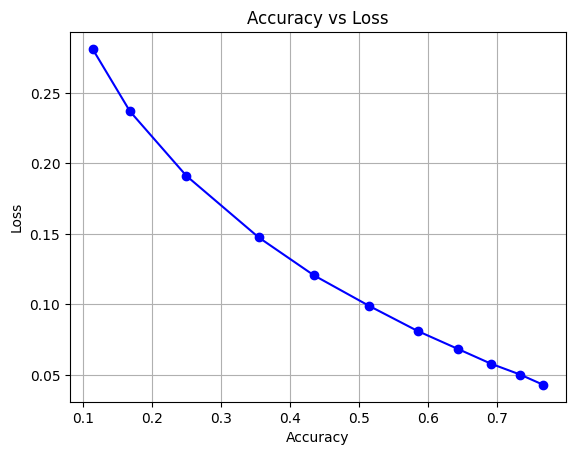

In [ ]:
plt.figure()
plt.plot(train_accuracies, train_losses, marker='o', color='blue')
plt.title("Accuracy vs Loss")
plt.xlabel("Accuracy")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


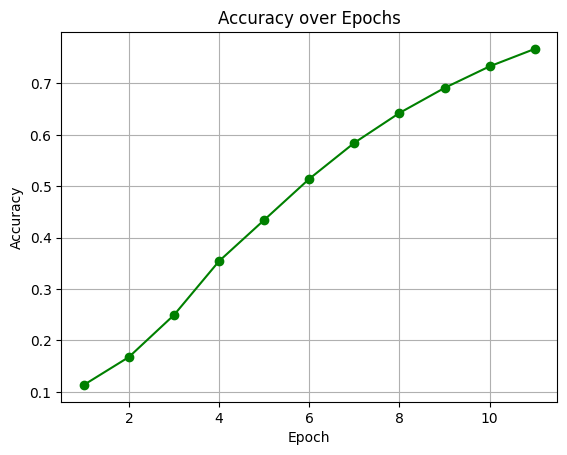

In [ ]:
plt.figure()
plt.plot(range(1, len(train_accuracies)+1), train_accuracies, marker='o', color='green')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


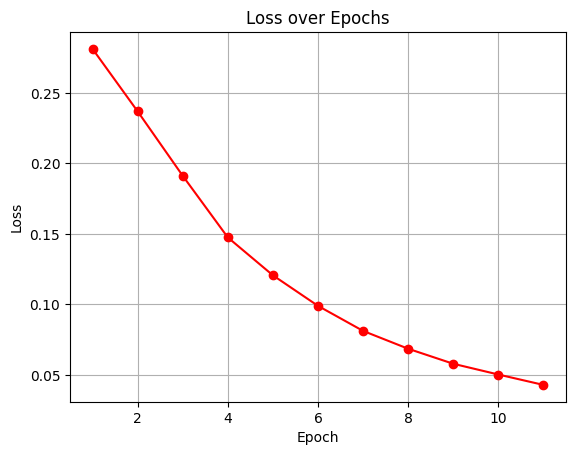

In [ ]:
plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', color='red')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


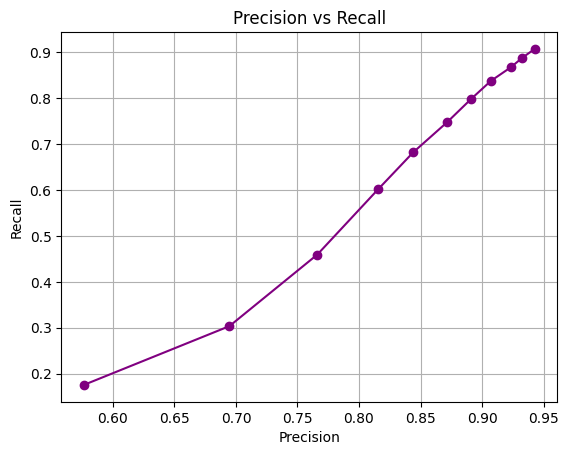

In [ ]:
plt.figure()
plt.plot(train_precisions, train_recalls, marker='o', color='purple')
plt.title("Precision vs Recall")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.grid(True)
plt.show()


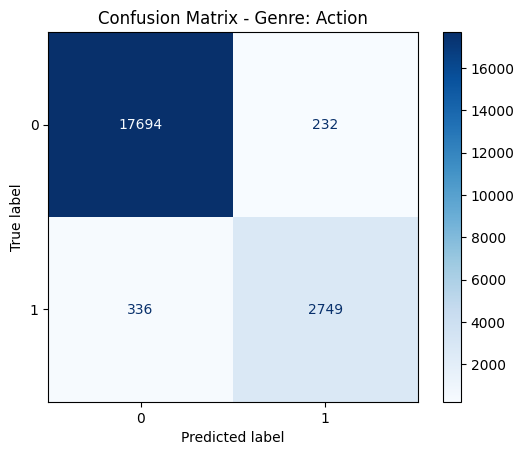

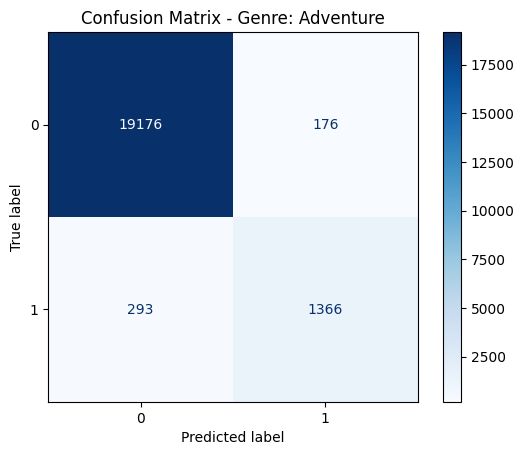

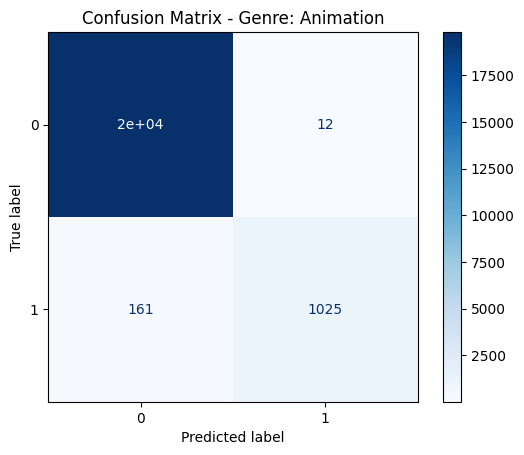

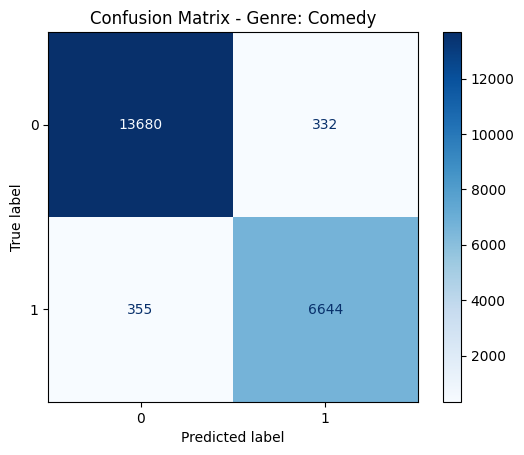

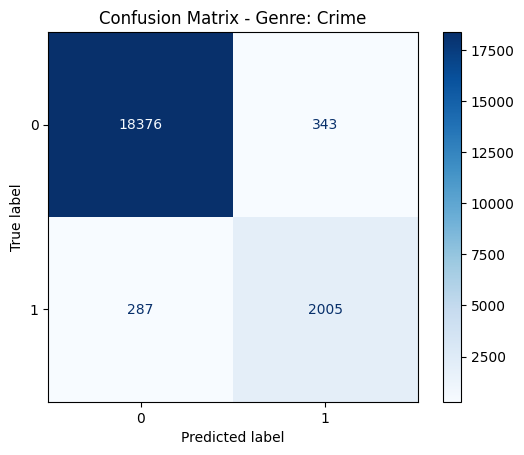

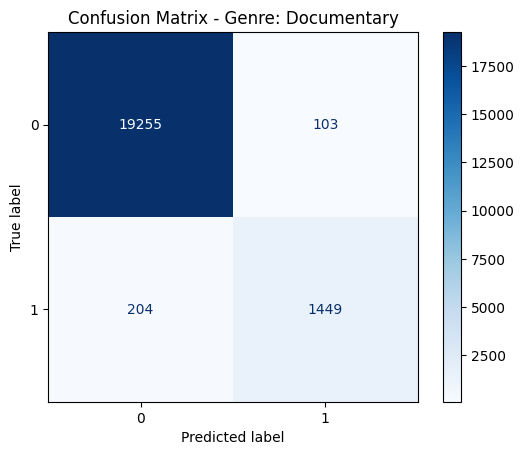

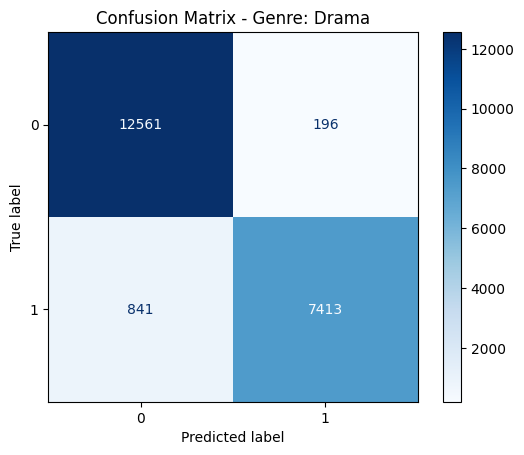

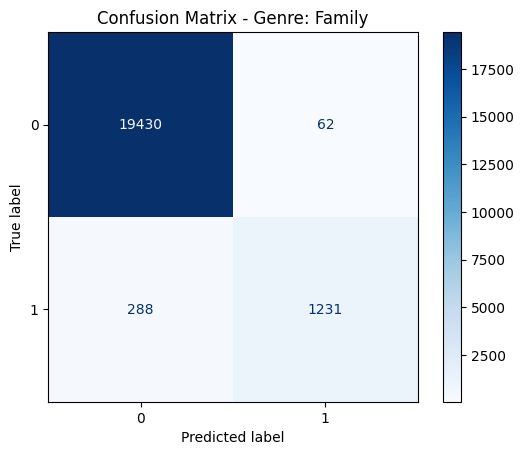

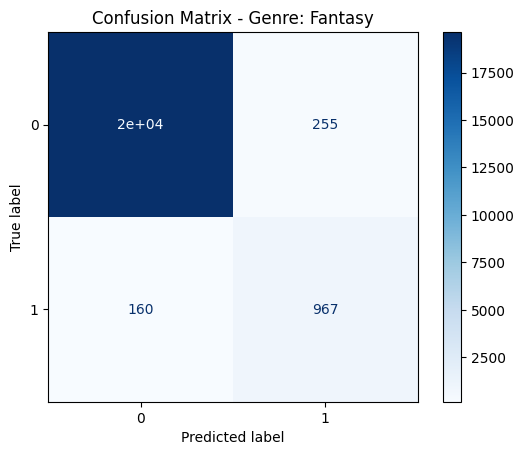

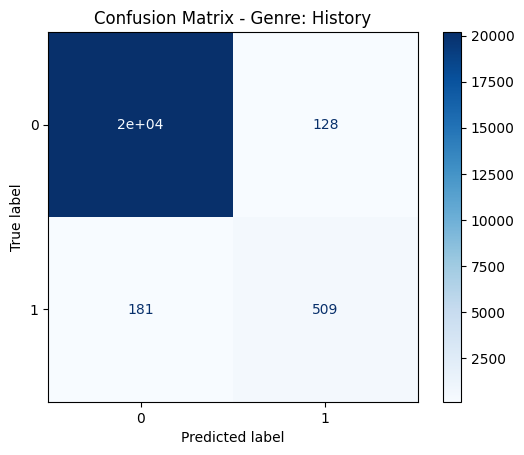

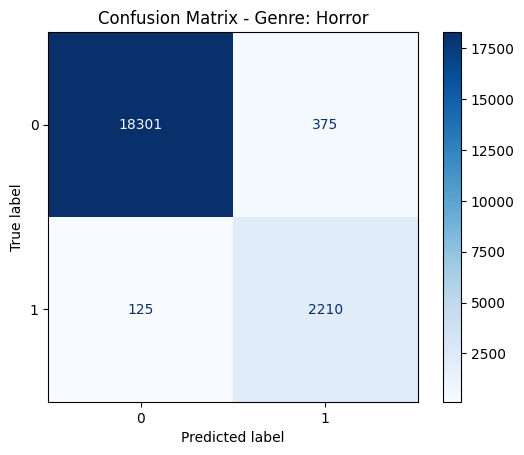

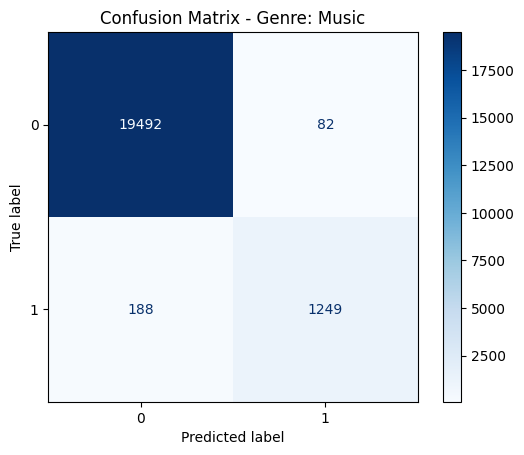

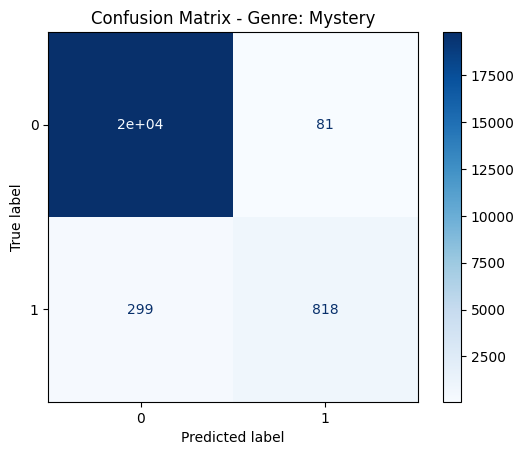

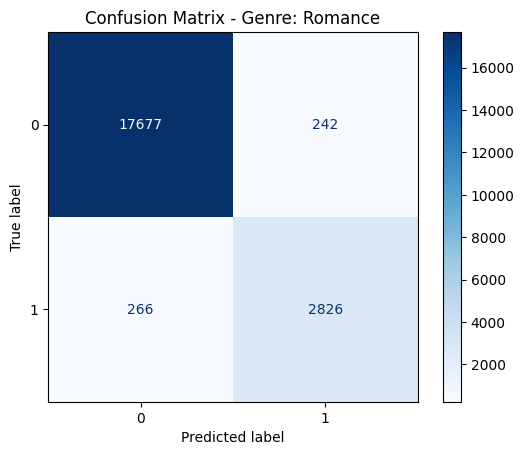

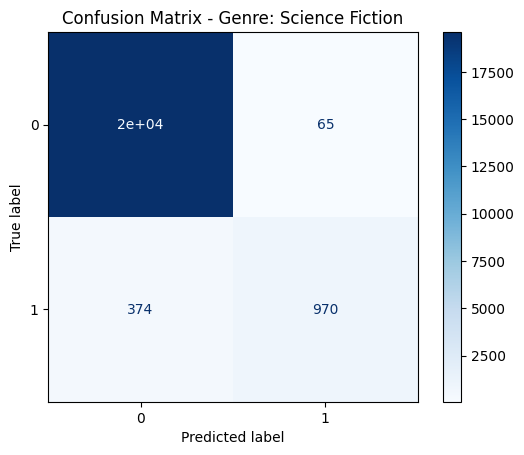

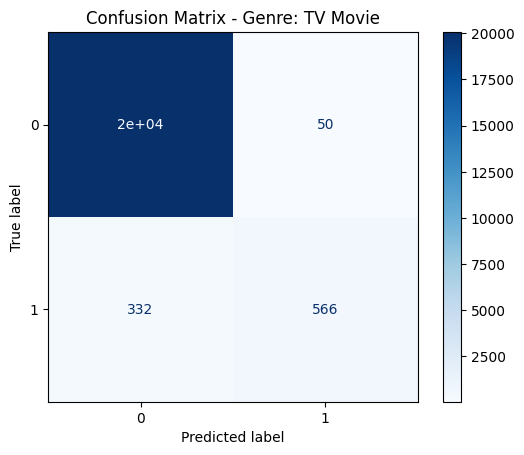

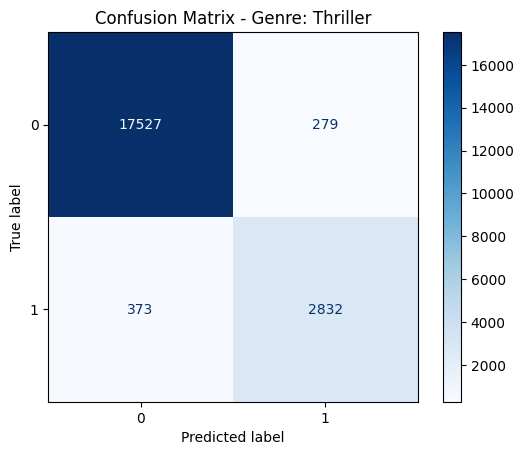

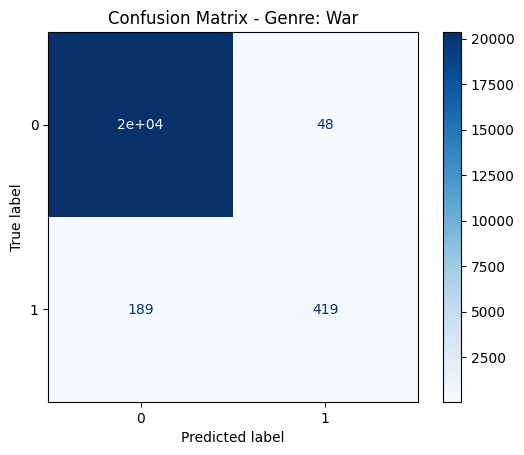

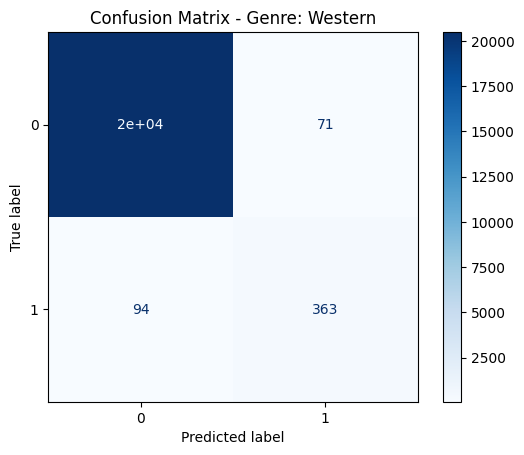

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for img, input_ids, attention_mask, labels in train_loader:
        img = img.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(img, input_ids, attention_mask)
        preds = (outputs > 0.5).int()

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)


genre_names = train_dataset.mlb.classes_

for i, genre in enumerate(genre_names):
    cm = confusion_matrix(all_labels[:, i], all_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - Genre: {genre}")
    plt.grid(False)
    plt.show()


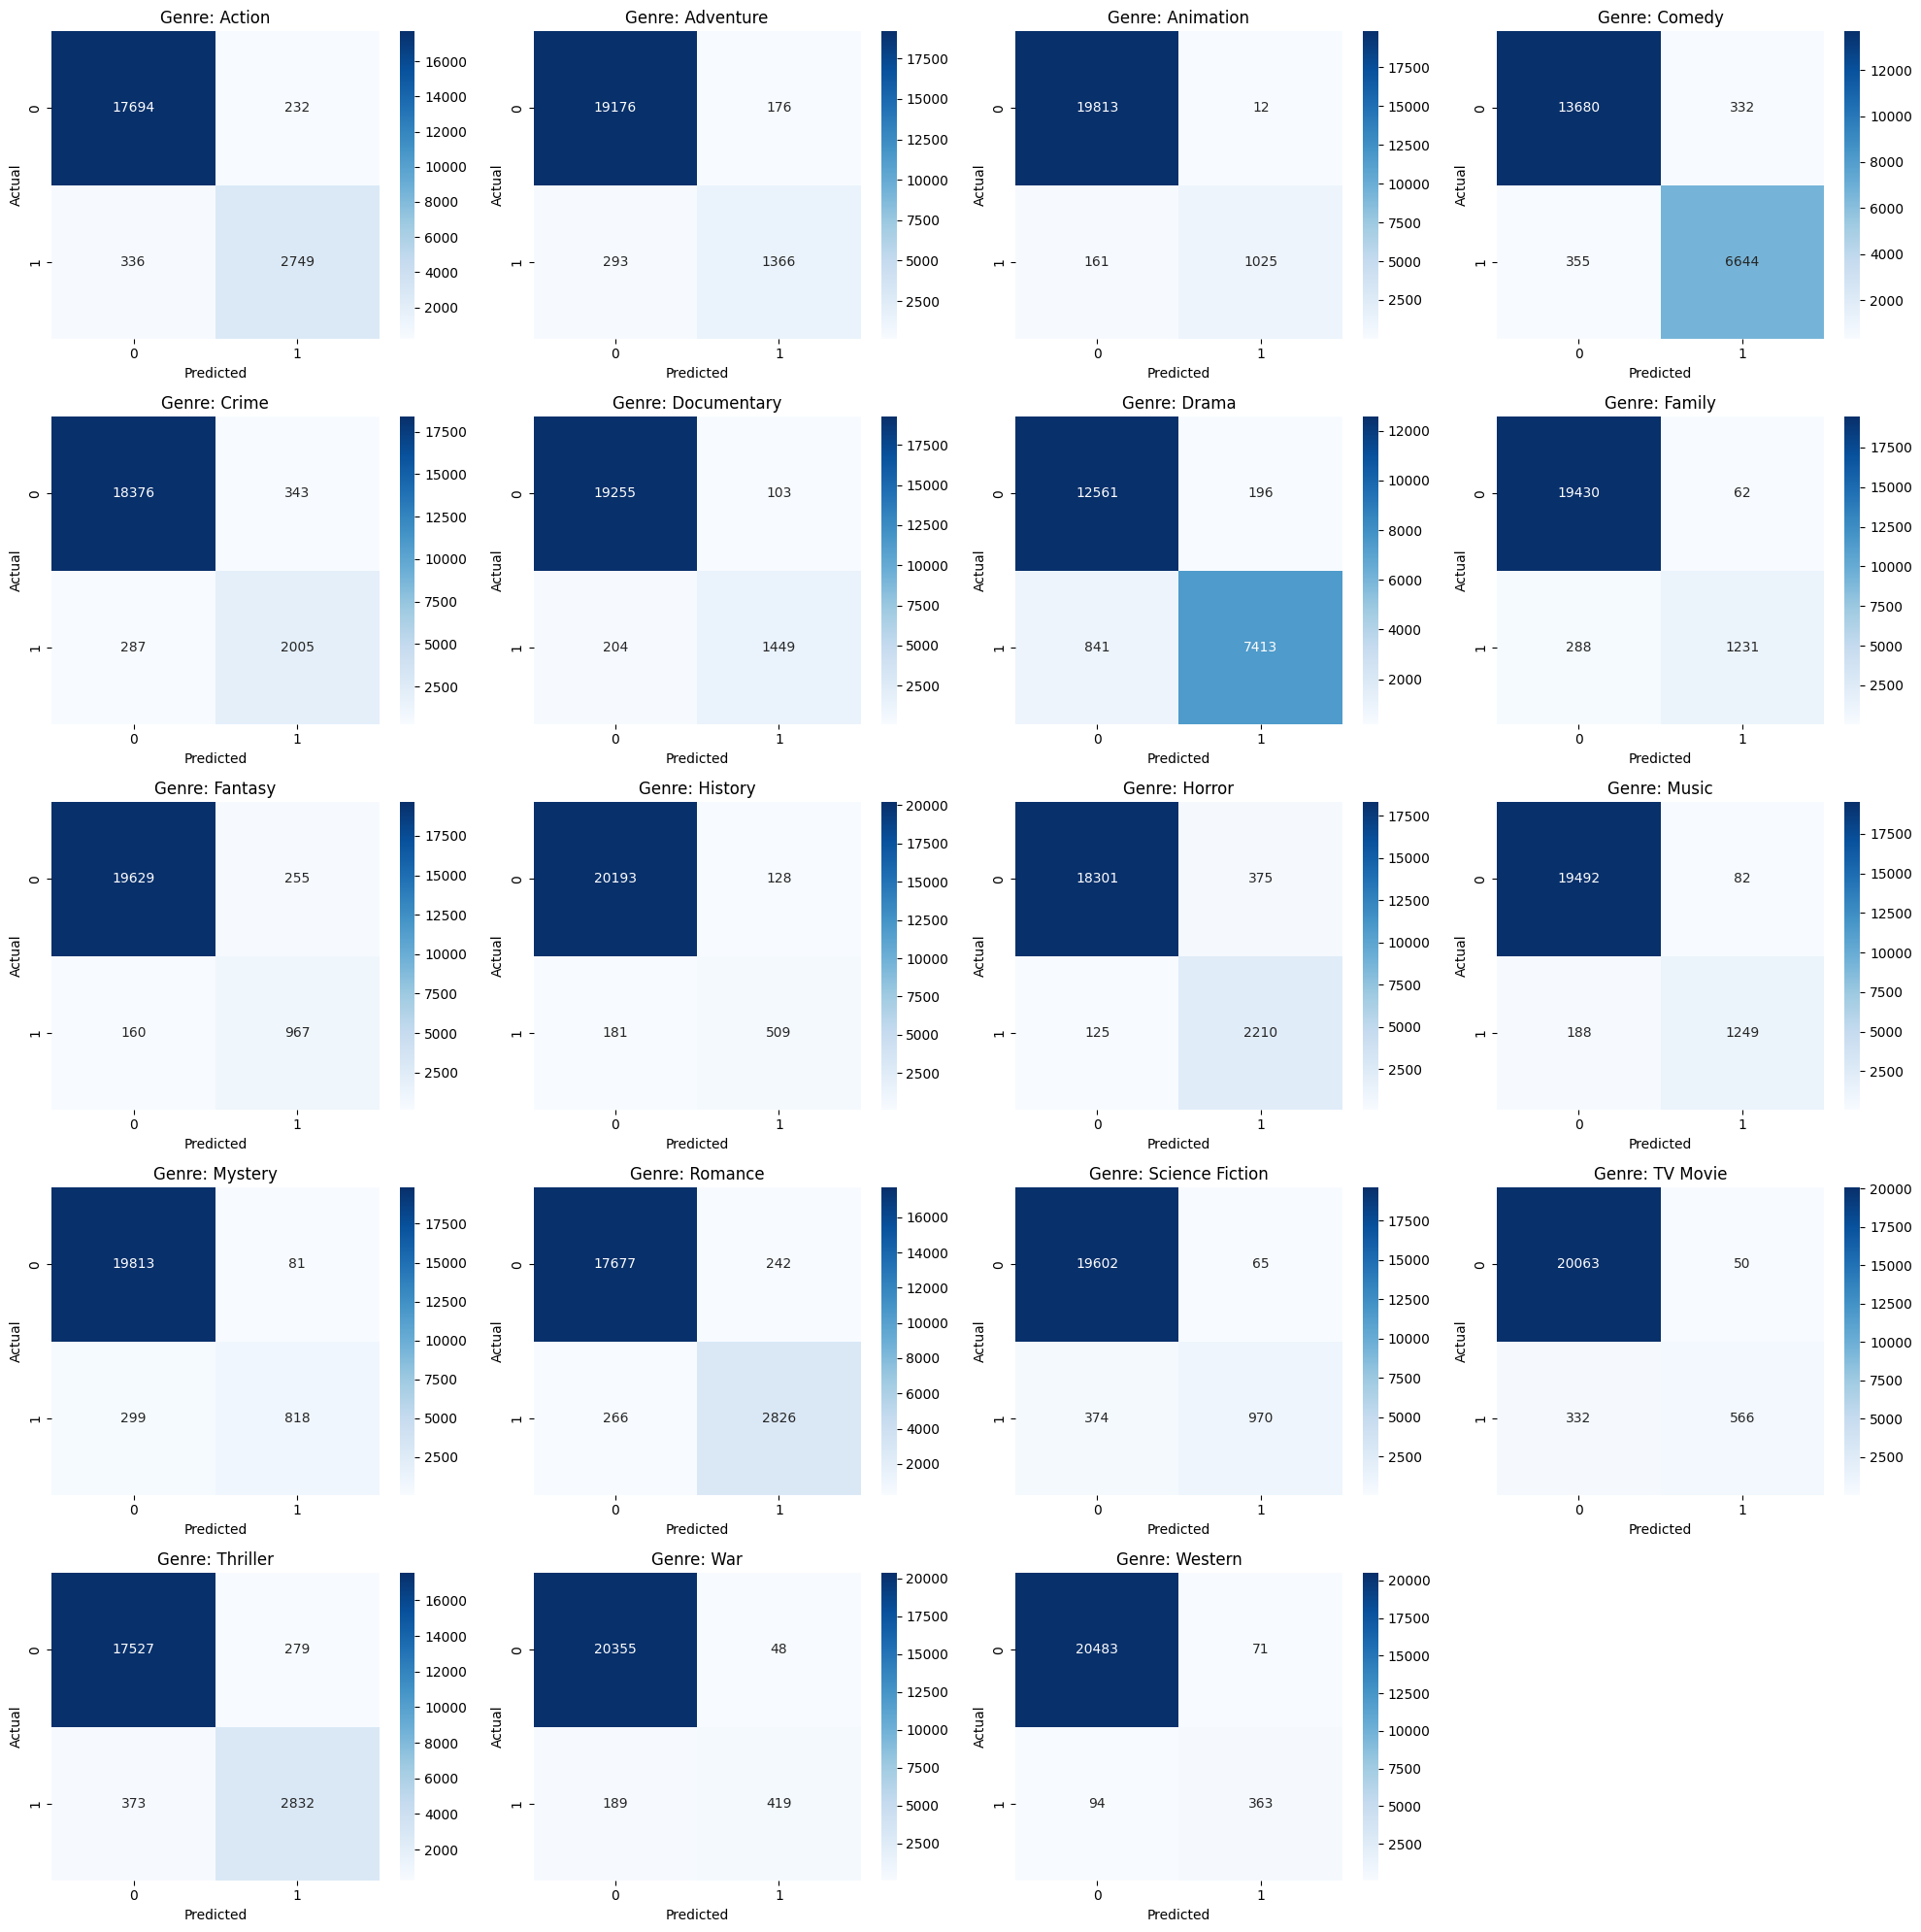

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import math

# Define the device here
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the final saved model
model.load_state_dict(torch.load("/content/drive/MyDrive/movie_recommendation/new_evaluation/models/final_model.pt"))
model.to(device)
model.eval()


all_preds, all_labels = [], []

with torch.no_grad():
    for img, input_ids, attention_mask, labels in train_loader:
        img = img.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(img, input_ids, attention_mask)
        preds = (outputs > 0.5).int()

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())


all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)


genre_names = train_dataset.mlb.classes_

conf_matrices = [confusion_matrix(all_labels[:, i], all_preds[:, i]) for i in range(len(genre_names))]


cols = 4
rows = math.ceil(len(genre_names) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, cm in enumerate(conf_matrices):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Genre: {genre_names[i]}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:

model_path = "/content/drive/MyDrive/movie_recommendation/new_evaluation/models/final_model.pt"


model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()


MultiModalClassifier(
  (cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


genre_names = [
    'Drama', 'Science Fiction', 'Adventure', 'History', 'Animation', 'Mystery',
    'Comedy', 'Western', 'TV Movie', 'Music', 'Foreign', 'Thriller', 'Family',
    'Documentary', 'Action', 'Romance', 'Fantasy', 'War', 'Horror'
]

def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for img, input_ids, attention_mask, labels in dataloader:
            img = img.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(img, input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    acc, prec, rec = compute_metrics(all_labels, all_preds)
    return total_loss / len(dataloader), acc, prec, rec, all_labels, all_preds

test_loss, test_acc, test_prec, test_rec, all_labels, all_preds = evaluate_model(model, test_loader, criterion)






In [ ]:


f1_score = 2 * (test_prec * test_rec) / (test_prec + test_rec)

print("\n=== Test Set Results ===")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print(f"Test Precision: {test_prec * 100:.2f}%")
print(f"Test Recall   : {test_rec * 100:.2f}%")
print(f"Test F1 Score : {f1_score * 100:.2f}%")







=== Test Set Results ===
Test Loss     : 0.2338
Test Accuracy : 61.00%
Test Precision: 67.00%
Test Recall   : 63.00%
Test F1 Score : 64.94%


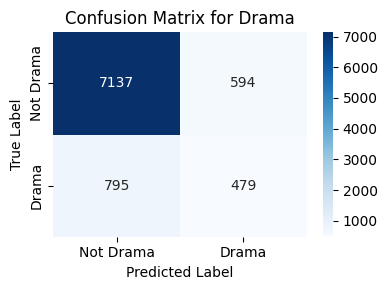

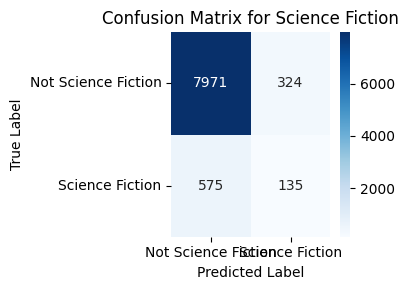

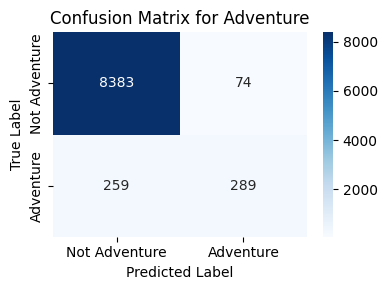

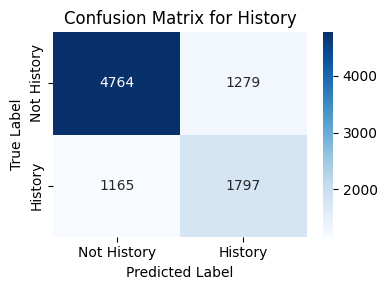

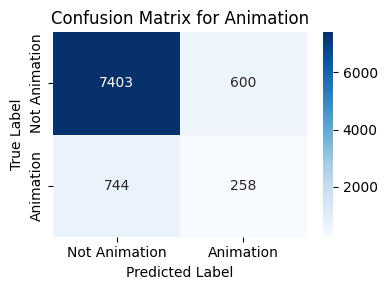

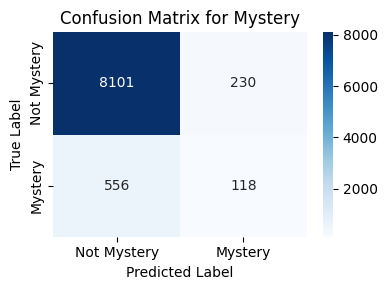

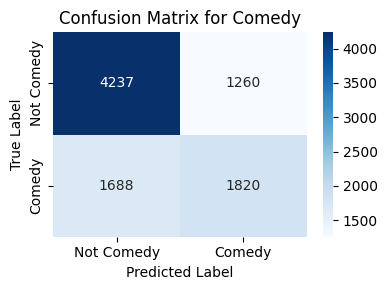

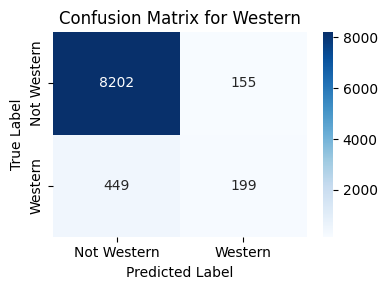

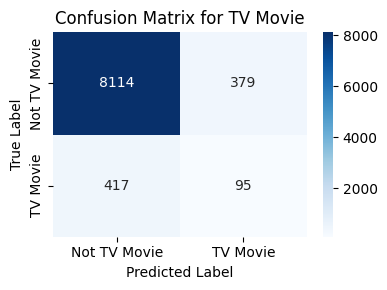

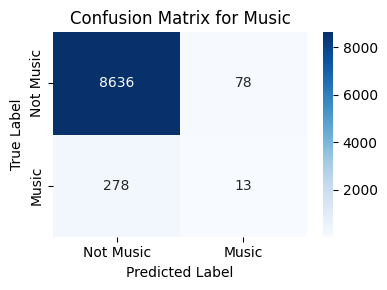

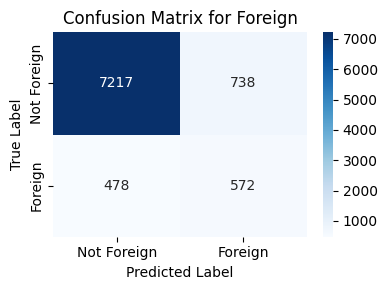

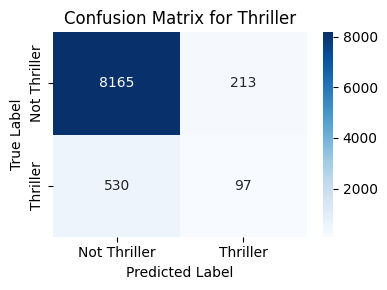

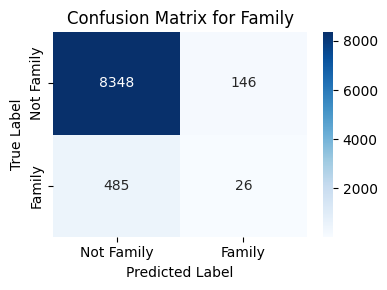

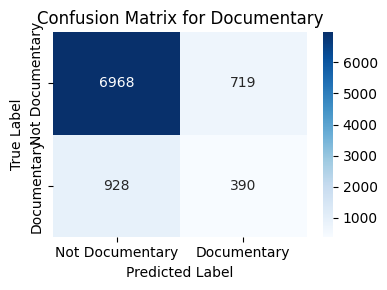

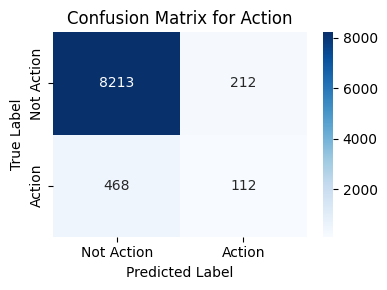

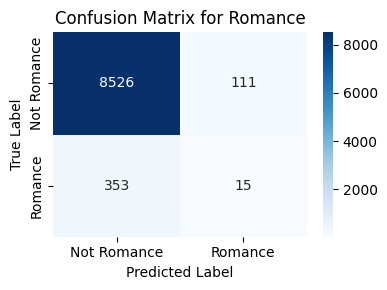

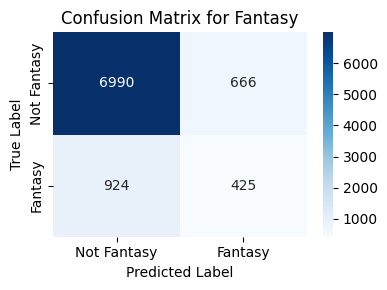

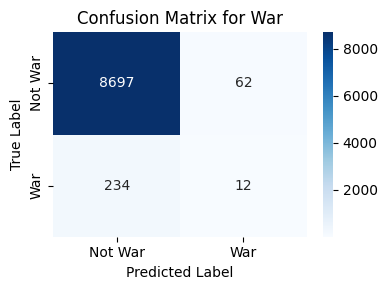

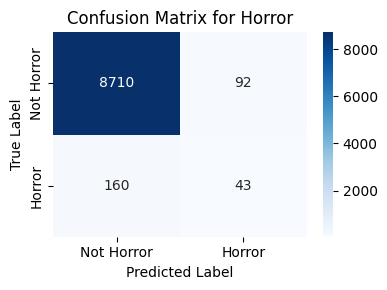

In [ ]:

threshold = 0.5
binary_preds = (all_preds >= threshold).astype(int)
binary_labels = all_labels.astype(int)

for i, genre in enumerate(genre_names):
    cm = confusion_matrix(binary_labels[:, i], binary_preds[:, i])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not " + genre, genre],
                yticklabels=["Not " + genre, genre])
    plt.title(f"Confusion Matrix for {genre}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()